## ML&Fintech HW6 Chapter 4 Question 14

Name: Alvin B. Lin\
ID: 112652040\
Date: 03/11/2025\
HW #: 6

In this problem, you will develop a model to predict whether a given
car gets high or low gas mileage based on the `Auto` data set.

(a) Create a binary variable, mpg01, that contains a 1 if mpg contains
a value above its median, and a 0 if mpg contains a value below
its median. You can compute the median using the median()
method of the data frame. Note you may find it helpful to add
a column mpg01 to the data frame by assignment. Assuming you
have stored the data frame as Auto, this can be done as follows:

$$\texttt{Auto['mpg01'] = mpg01}$$

In [4]:
from ISLP import load_data
import pandas as pd
import numpy as np

Auto = load_data('Auto')
median_mpg = Auto['mpg'].median()
Auto['mpg01'] = np.where(Auto['mpg'] > median_mpg, 1, 0)

(b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other
features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

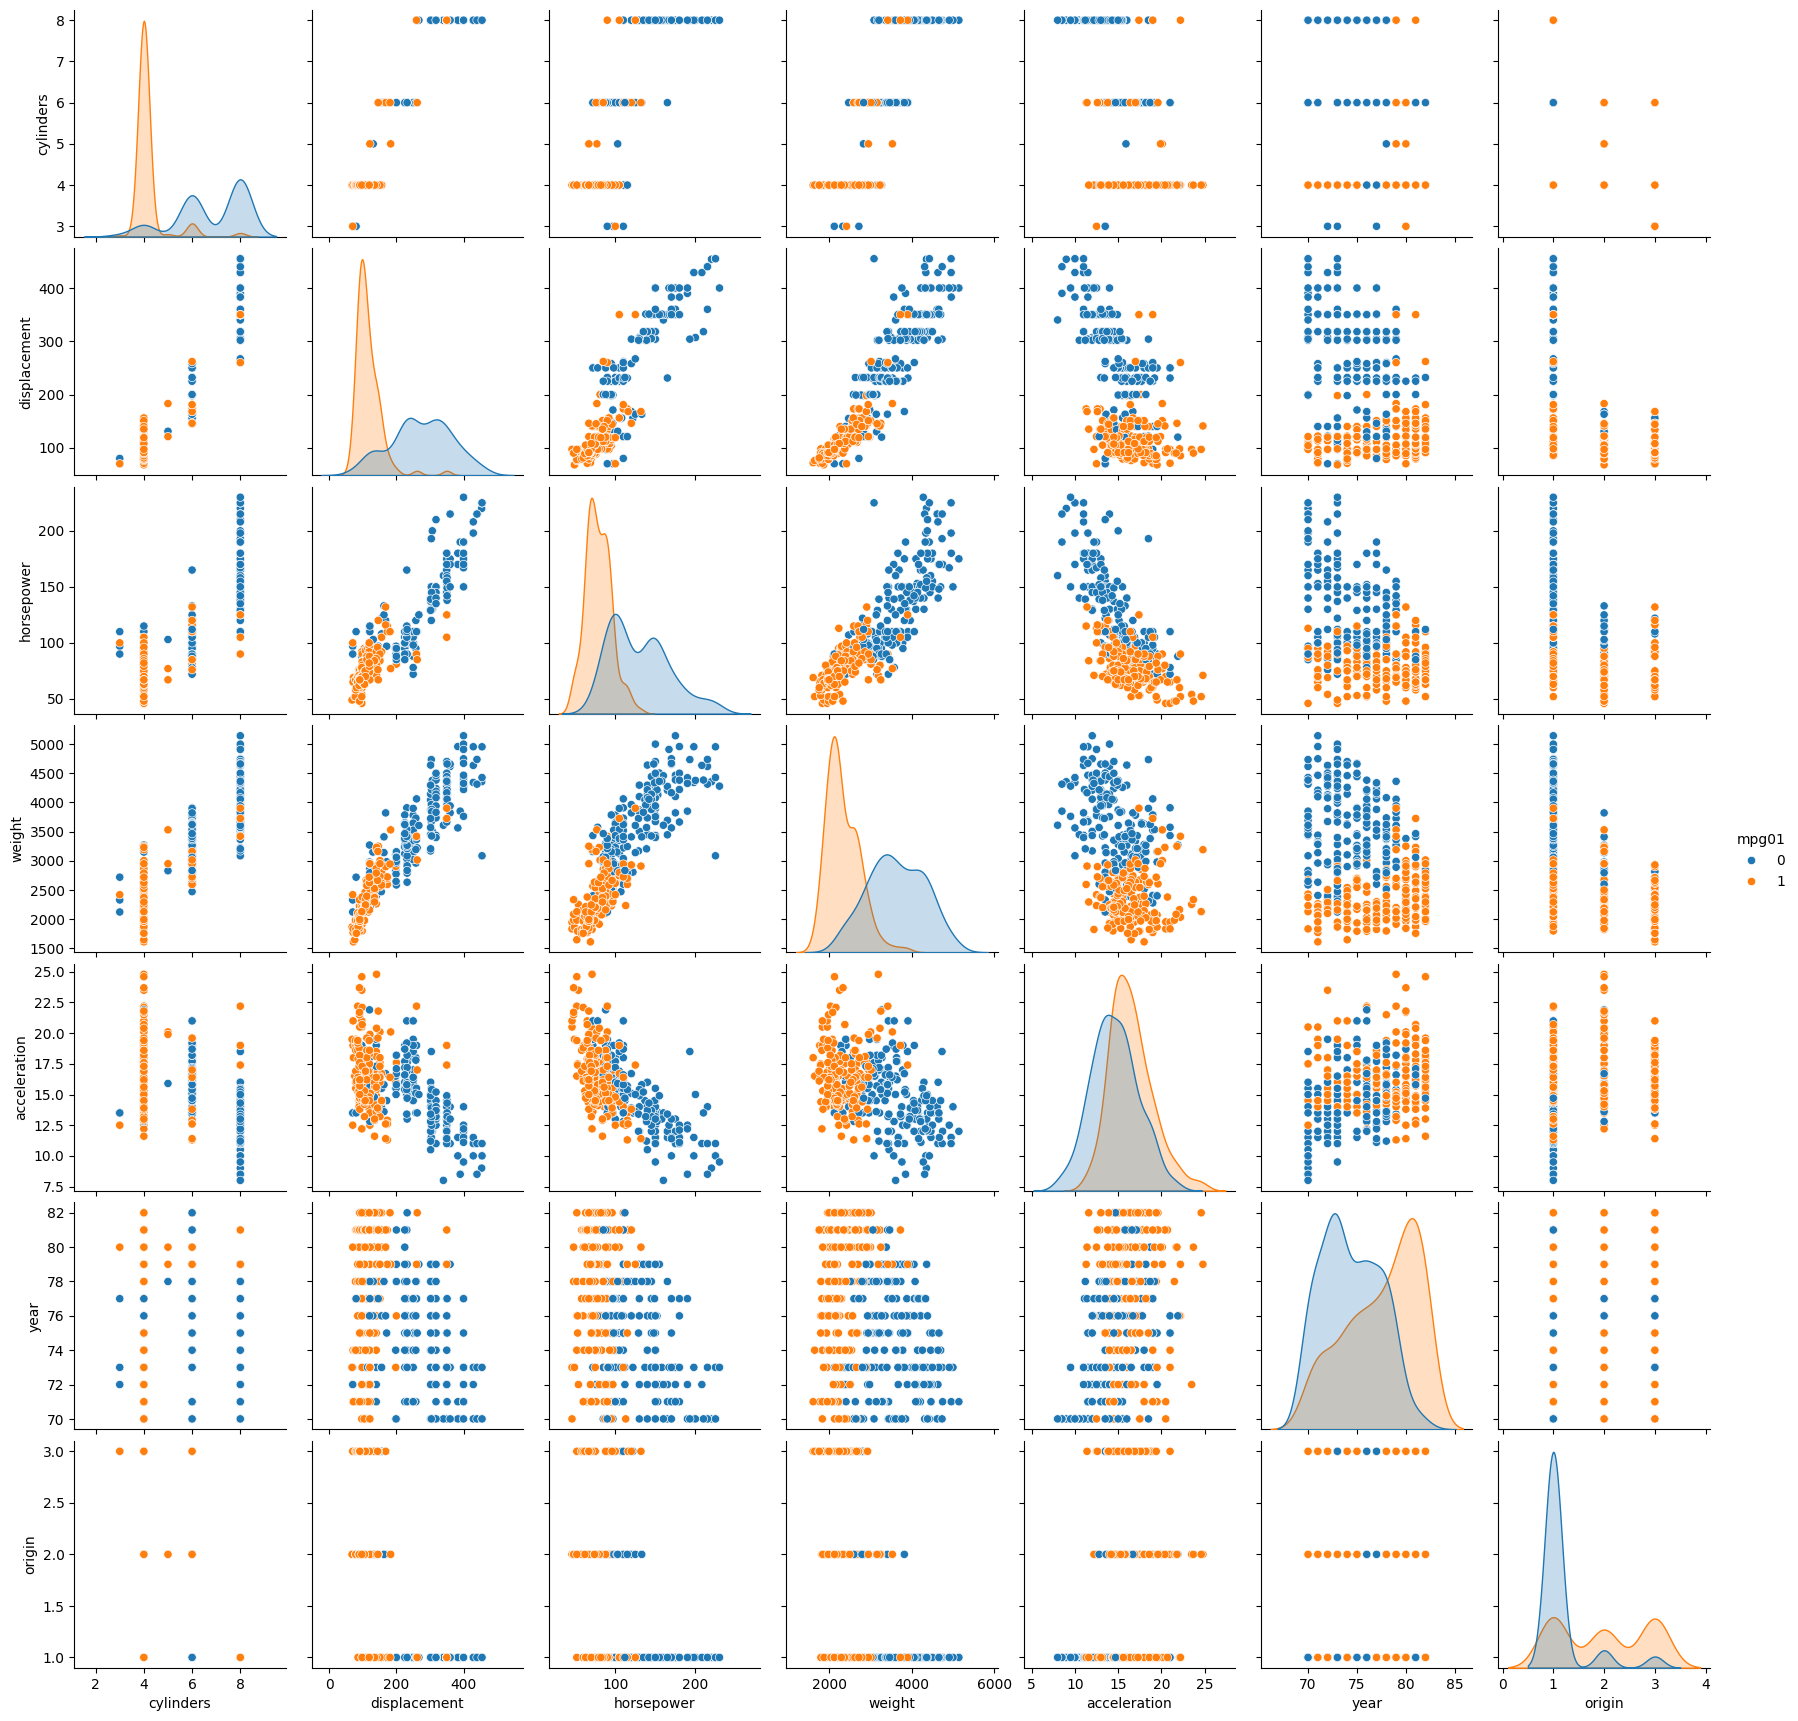

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(Auto, hue='mpg01', vars=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin'])
plt.show()

Except for `accelaration`,`origin` and `year`, it seems that every other predictors tend to have `mgp01` value 1 when their value is low. 

---

(c) Split the data into a training set and a test set.

In [14]:
# split the data into training and testing sets
from sklearn.model_selection import train_test_split
train, test = train_test_split(Auto, test_size=0.2, random_state=42)

---

(d) Perform LDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

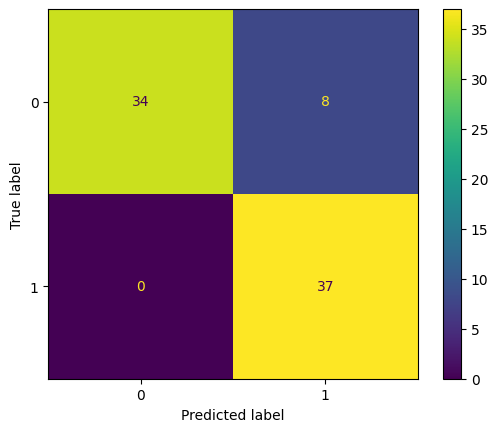

In [27]:
# using LDA to do (b)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(train[['cylinders', 'displacement', 'horsepower', 'weight']], train['mpg01'])
pred_lda = lda.predict(test[['cylinders', 'displacement', 'horsepower', 'weight']])
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
cm_lda = confusion_matrix(test['mpg01'], pred_lda)
acc_lda = accuracy_score(test['mpg01'], pred_lda)
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=lda.classes_)
disp_lda.plot()

In [28]:
# calculate the test error
test_error_lda = 1 - acc_lda
print(f"LDA Test Error: {test_error_lda:.4f}")

LDA Test Error: 0.1013


---

(e) Perform QDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?


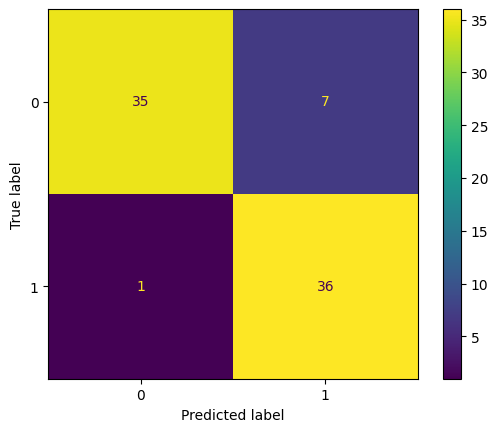

In [29]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(train[['cylinders', 'displacement', 'horsepower', 'weight']], train['mpg01'])
pred_qda = qda.predict(test[['cylinders', 'displacement', 'horsepower', 'weight']])
cm_qda = confusion_matrix(test['mpg01'], pred_qda)
acc_qda = accuracy_score(test['mpg01'], pred_qda)
disp_qda = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=qda.classes_)
disp_qda.plot()

In [30]:
test_error_qda = 1 - acc_qda
print(f"QDA Test Error: {test_error_qda:.4f}")

QDA Test Error: 0.1013


---

(f) Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with
mpg01 in (b). What is the test error of the model obtained?


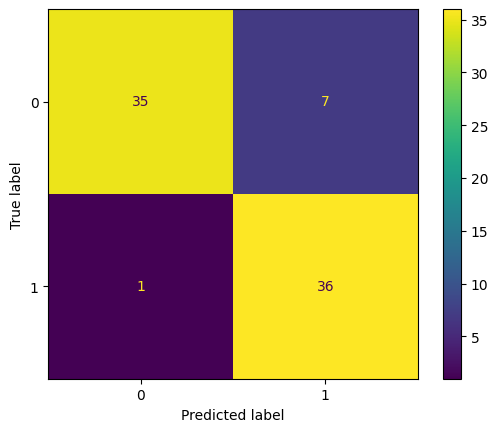

In [31]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(train[['cylinders', 'displacement', 'horsepower', 'weight']], train['mpg01'])
pred_logreg = logreg.predict(test[['cylinders', 'displacement', 'horsepower', 'weight']])
cm_logreg = confusion_matrix(test['mpg01'], pred_logreg)
acc_logreg = accuracy_score(test['mpg01'], pred_logreg)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=logreg.classes_)
disp_logreg.plot()

In [32]:
test_error_logreg = 1 - acc_logreg
print(f"Logistic Regression Test Error: {test_error_logreg:.4f}")

Logistic Regression Test Error: 0.1013


---

(g) Perform naive Bayes on the training data in order to predict
mpg01 using the variables that seemed most associated with mpg01
in (b). What is the test error of the model obtained?

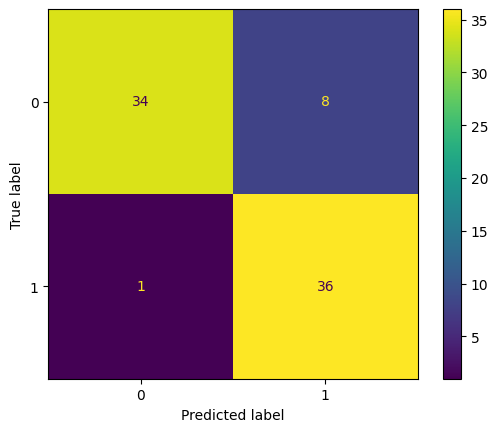

In [33]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(train[['cylinders', 'displacement', 'horsepower', 'weight']], train['mpg01'])
pred_nb = nb.predict(test[['cylinders', 'displacement', 'horsepower', 'weight']])
cm_nb = confusion_matrix(test['mpg01'], pred_nb)
acc_nb = accuracy_score(test['mpg01'], pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb.classes_)
disp_nb.plot()

In [34]:
test_error_nb = 1 - acc_nb
print(f"Naive Bayes Test Error: {test_error_nb:.4f}")

Naive Bayes Test Error: 0.1139


---

(h) Perform KNN on the training data, with several values of K, in
order to predict mpg01. Use only the variables that seemed most
associated with mpg01 in (b). What test errors do you obtain?
Which value of K seems to perform the best on this data set?

In [36]:
from sklearn.neighbors import KNeighborsClassifier
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train[['cylinders', 'displacement', 'horsepower', 'weight']], train['mpg01'])
    pred_knn = knn.predict(test[['cylinders', 'displacement', 'horsepower', 'weight']])
    acc_knn = accuracy_score(test['mpg01'], pred_knn)
    test_error_knn = 1 - acc_knn
    print(f"KNN (k={k}) Test Error: {test_error_knn:.4f}")

KNN (k=1) Test Error: 0.1646
KNN (k=2) Test Error: 0.1519
KNN (k=3) Test Error: 0.0759
KNN (k=4) Test Error: 0.1139
KNN (k=5) Test Error: 0.1139
KNN (k=6) Test Error: 0.1013
KNN (k=7) Test Error: 0.1139
KNN (k=8) Test Error: 0.1139
KNN (k=9) Test Error: 0.1392
KNN (k=10) Test Error: 0.1139
KNN (k=11) Test Error: 0.1519
KNN (k=12) Test Error: 0.1139
KNN (k=13) Test Error: 0.1266
KNN (k=14) Test Error: 0.1139
KNN (k=15) Test Error: 0.1392
KNN (k=16) Test Error: 0.1392
KNN (k=17) Test Error: 0.1519
KNN (k=18) Test Error: 0.1519
KNN (k=19) Test Error: 0.1519
KNN (k=20) Test Error: 0.1519


The result shows that when $k=3$, the knn model performs the best, with scale of test error.